In [1]:
from google.colab import files

# Kaggle API anahtarınızı yükleyin (kaggle.json dosyası)
files.upload()

# Anahtarı doğru dizine taşıyın ve izinleri ayarlayın
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
# Dataseti indirin (URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease)
!kaggle datasets download -d mansoordaku/ckdisease

# Zip dosyasını açın
!unzip ckdisease.zip

Dataset URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease
License(s): unknown
  0% 0.00/9.51k [00:00<?, ?B/s]
100% 9.51k/9.51k [00:00<00:00, 13.9MB/s]
Archive:  ckdisease.zip
  inflating: kidney_disease.csv      


In [3]:
!ls  # kidney_disease.csv dosyasını göreceksiniz

ckdisease.zip  kidney_disease.csv  sample_data


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder


In [5]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
df.drop("id",axis=1,inplace=True)

In [7]:
df.columns = ["age","blood_presure","specific_gravity","albumin","sugar",
              "red_blood_cells","pus_cell","pus_cell_clumbs",
              "bacteria","blood_glucose_random","blood_urea",
              "serum_creatinine","sodium","potassium","hemoglobin",
              "packed_cell_volume","white_blood_cell_count","red_blood_cell_count",
              "hypertension","diabetes_mellitus","coronary_artery_disease",
              "appetite","peda_edema","aanemia","class"]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_presure            388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumbs          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

In [9]:
describe = df.describe()
describe

,age,blood_presure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [10]:
df["packed_cell_volume"] = pd.to_numeric(df["packed_cell_volume"],errors="coerce")
df["white_blood_cell_count"] = pd.to_numeric(df["white_blood_cell_count"],errors="coerce")
df["red_blood_cell_count"] = pd.to_numeric(df["red_blood_cell_count"],errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_presure            388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumbs          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

In [12]:
cat_cols = [col for col in df.columns if df[col].dtype=="object"] #categorik veri
num_cols = [col for col in df.columns if df[col].dtype!="object"] # float,int -> numetric

In [13]:
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumbs: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' ' yes' '\tno' '\tyes' nan]
coronary_artery_disease: ['no' 'yes' '\tno' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
aanemia: ['no' 'yes' nan]
class: ['ckd' 'ckd\t' 'notckd']


In [14]:
df["diabetes_mellitus"].replace(to_replace={"\tyes":"yes","\tno":"no",' yes':"yes"},inplace=True)
df["coronary_artery_disease"].replace(to_replace={"\tno":"no"},inplace=True)
df["class"].replace(to_replace={'ckd\t':'ckd'},inplace=True)

<ipython-input-14-c796aa7b8bc8>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["diabetes_mellitus"].replace(to_replace={"\tyes":"yes","\tno":"no",' yes':"yes"},inplace=True)
<ipython-input-14-c796aa7b8bc8>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

In [15]:
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumbs: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' nan]
coronary_artery_disease: ['no' 'yes' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
aanemia: ['no' 'yes' nan]
class: ['ckd' 'notckd']


In [16]:
df["class"] = df["class"].map({"ckd":0,"notckd":1})

<ipython-input-20-dee986602d92>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
<ipython-input-20-dee986602d92>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
<ipython-input-20-dee986602d92>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn

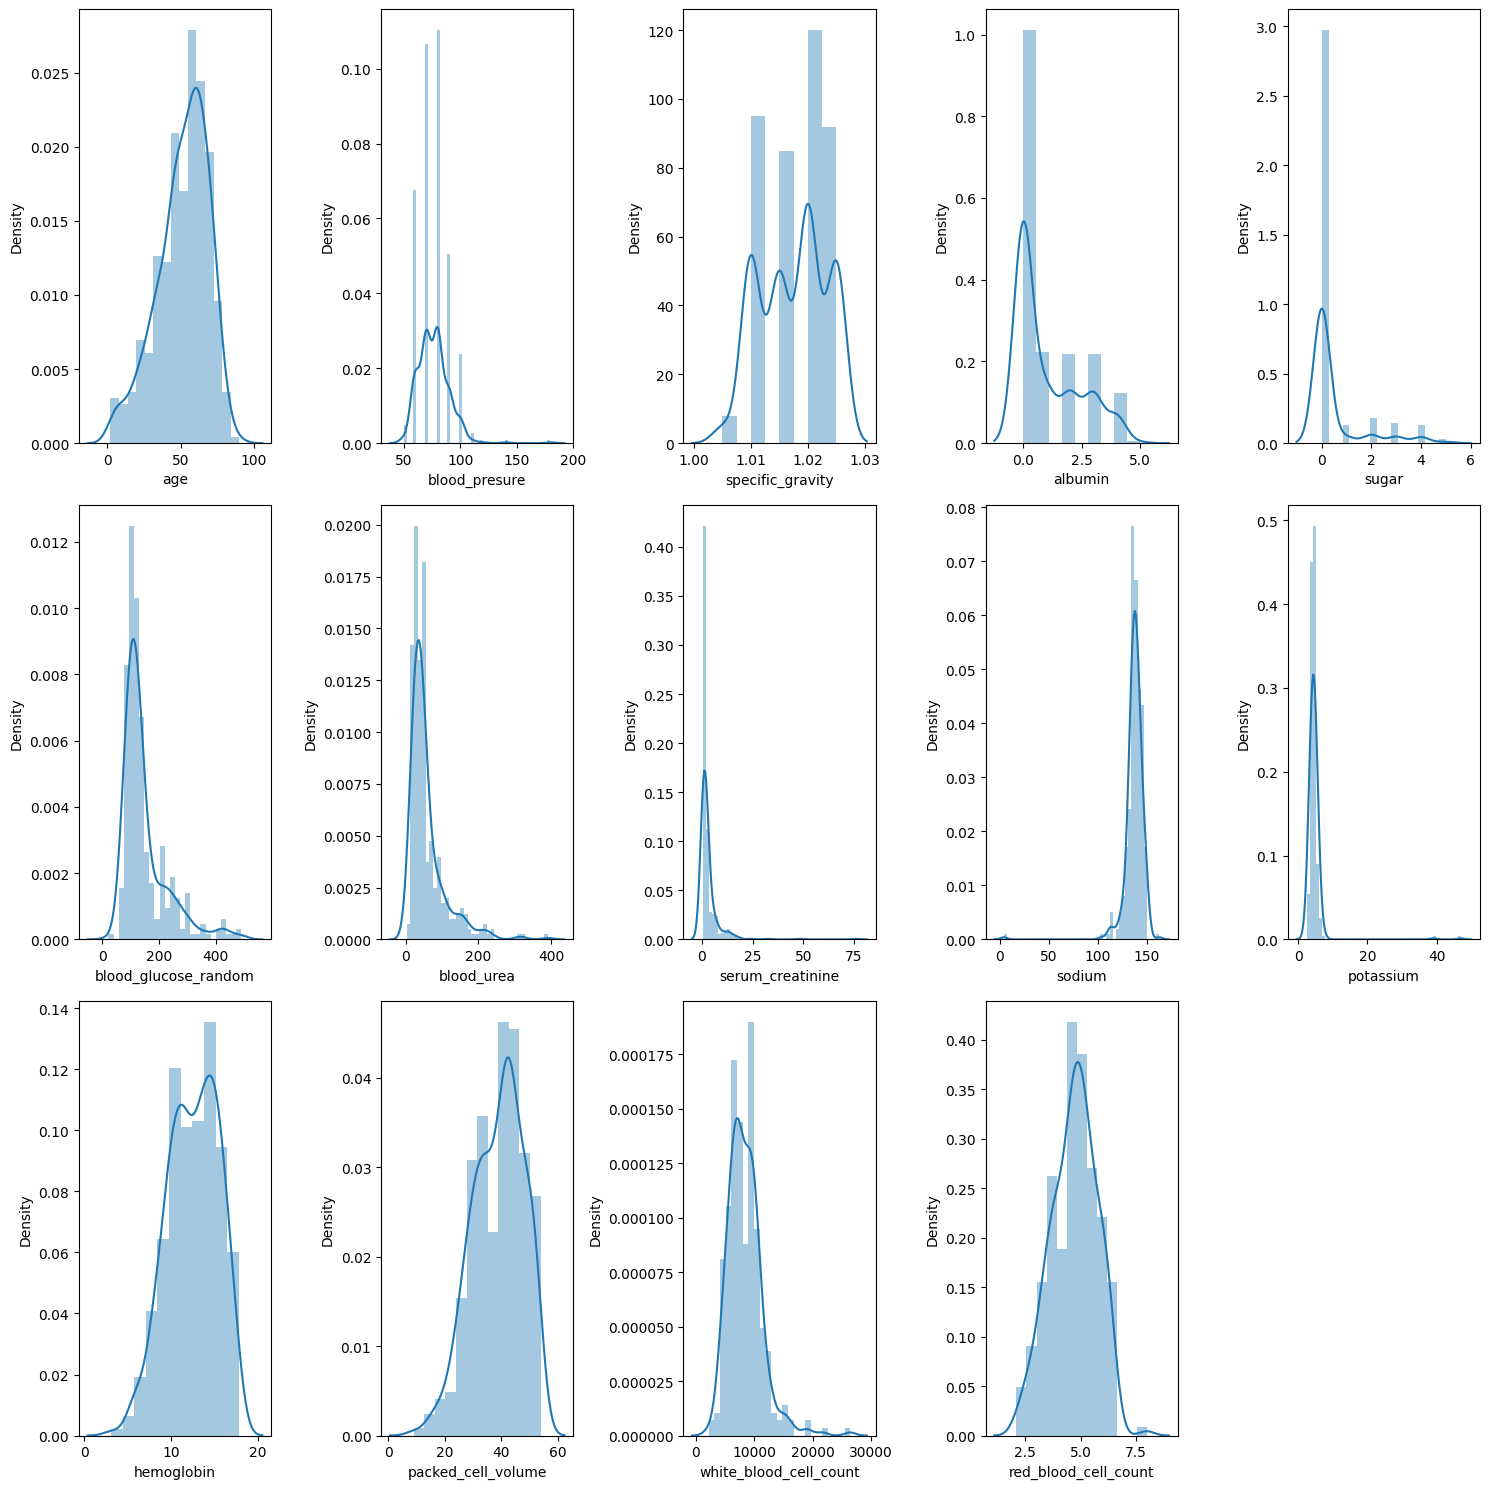

In [20]:
plt.figure(figsize=(15,15))
plotnumber = 1

for col in num_cols:
  if plotnumber <= 14:
    ax = plt.subplot(3,5,plotnumber)
    sns.distplot(df[col])
    plt.xlabel(col)
  plotnumber += 1
plt.tight_layout()
plt.show()

In [21]:
def kde(col):
  grid = sns.FacetGrid(df,hue="class",height=6,aspect=2)
  grid.map(sns.kdeplot,col)
  grid.add_legend()

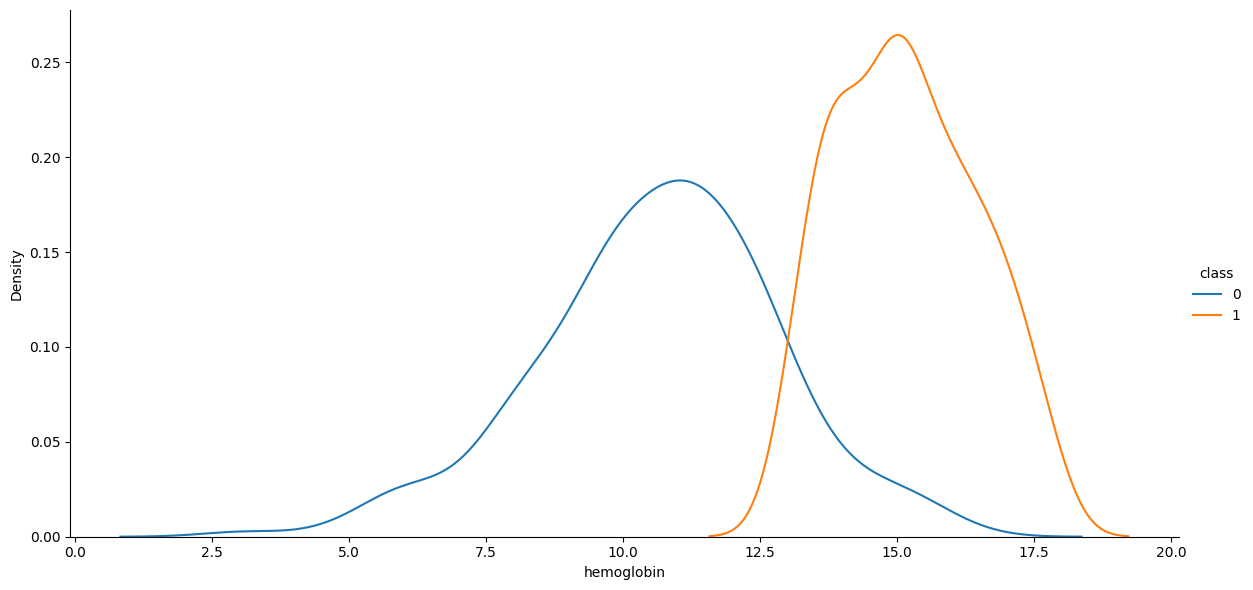

In [22]:
kde("hemoglobin")

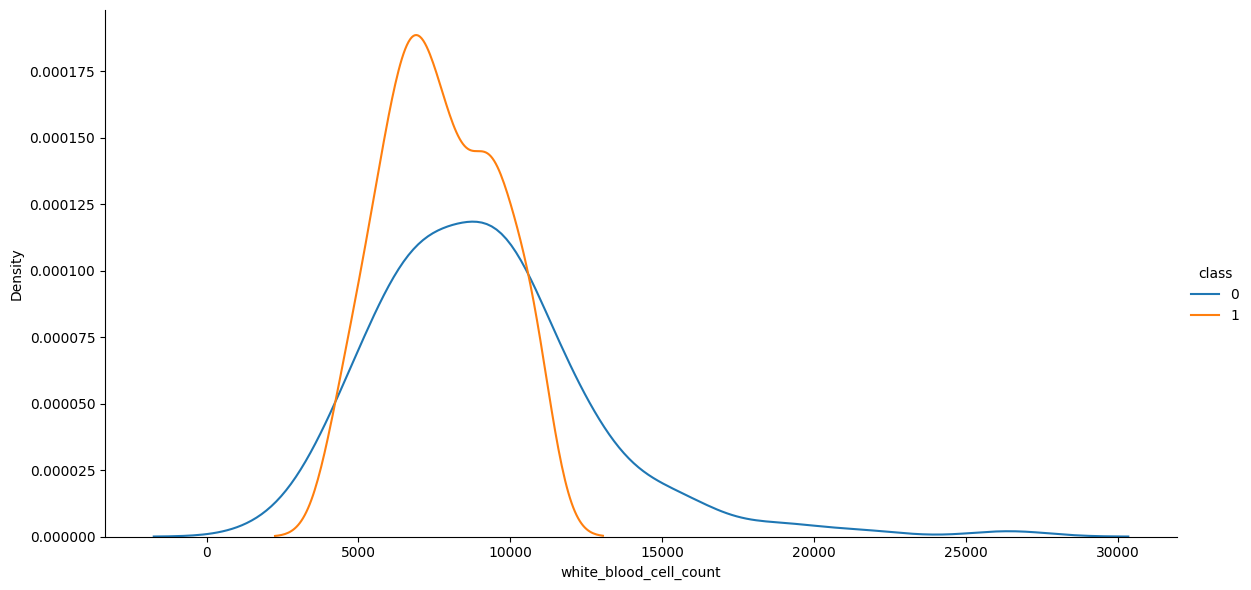

In [23]:
kde("white_blood_cell_count")

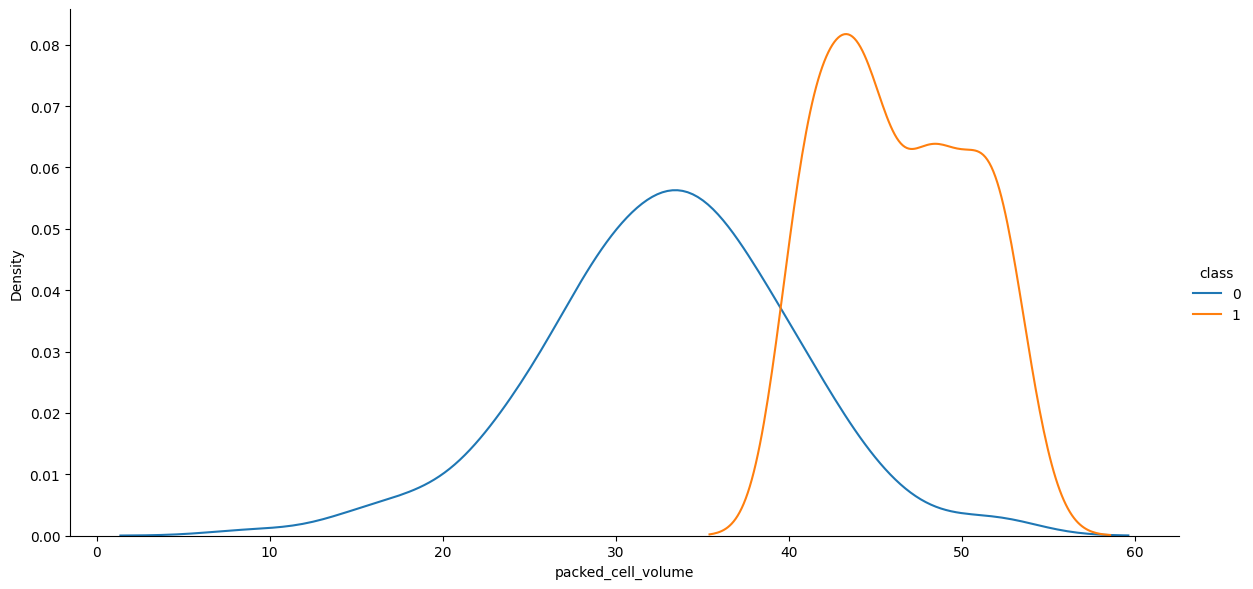

In [24]:
kde("packed_cell_volume")

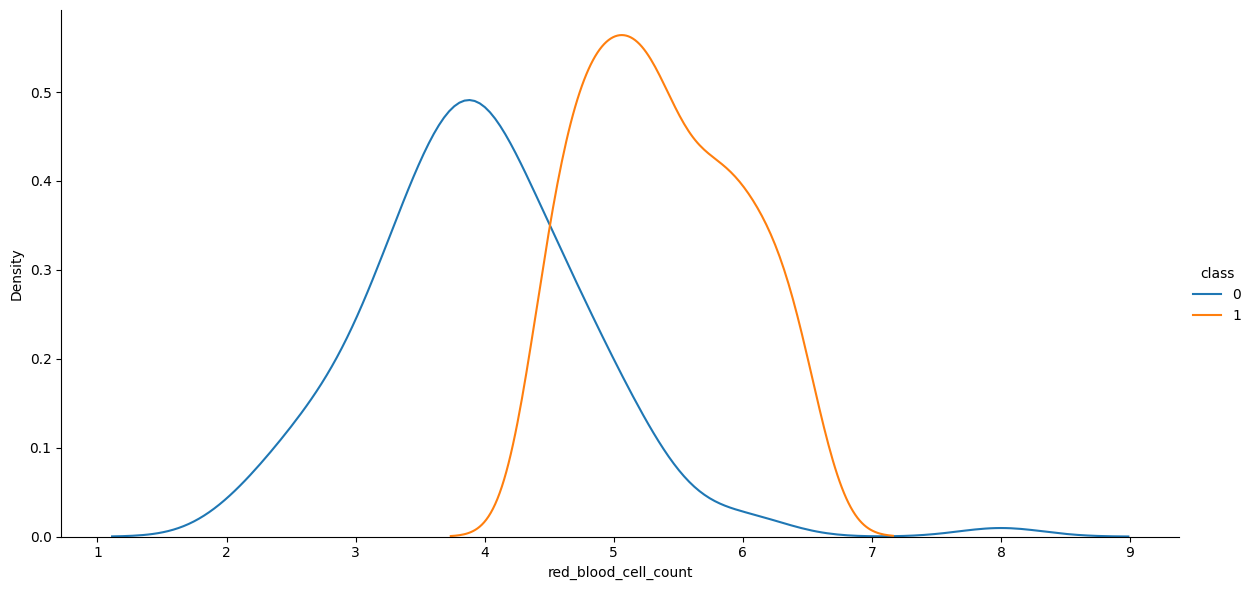

In [25]:
kde("red_blood_cell_count")

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


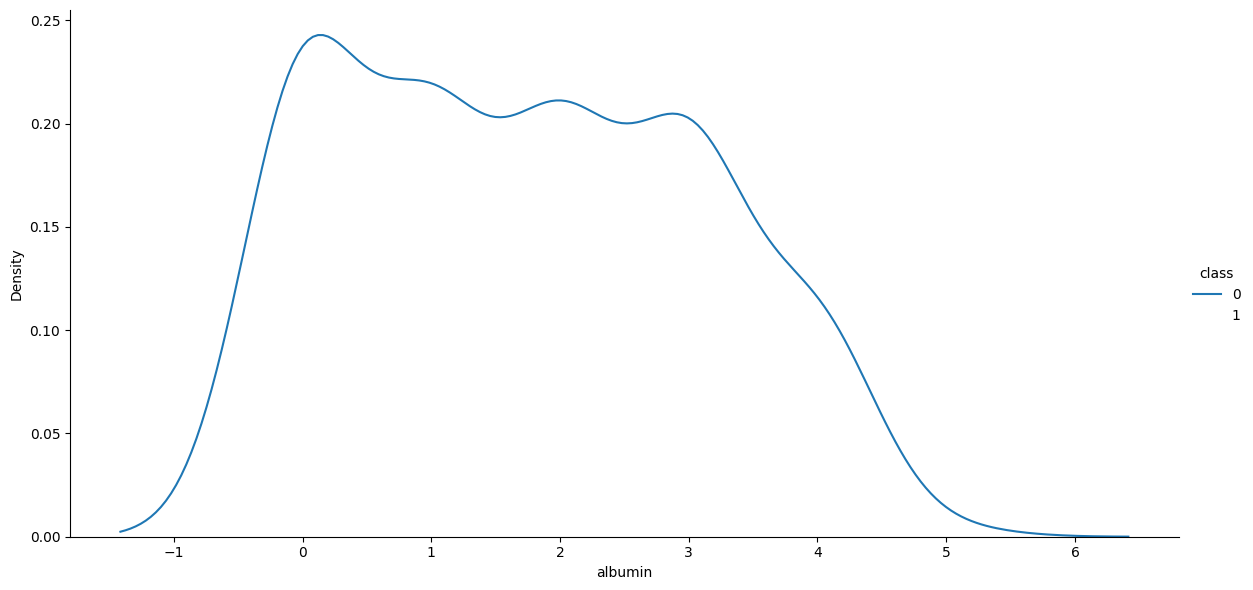

In [26]:
kde("albumin")

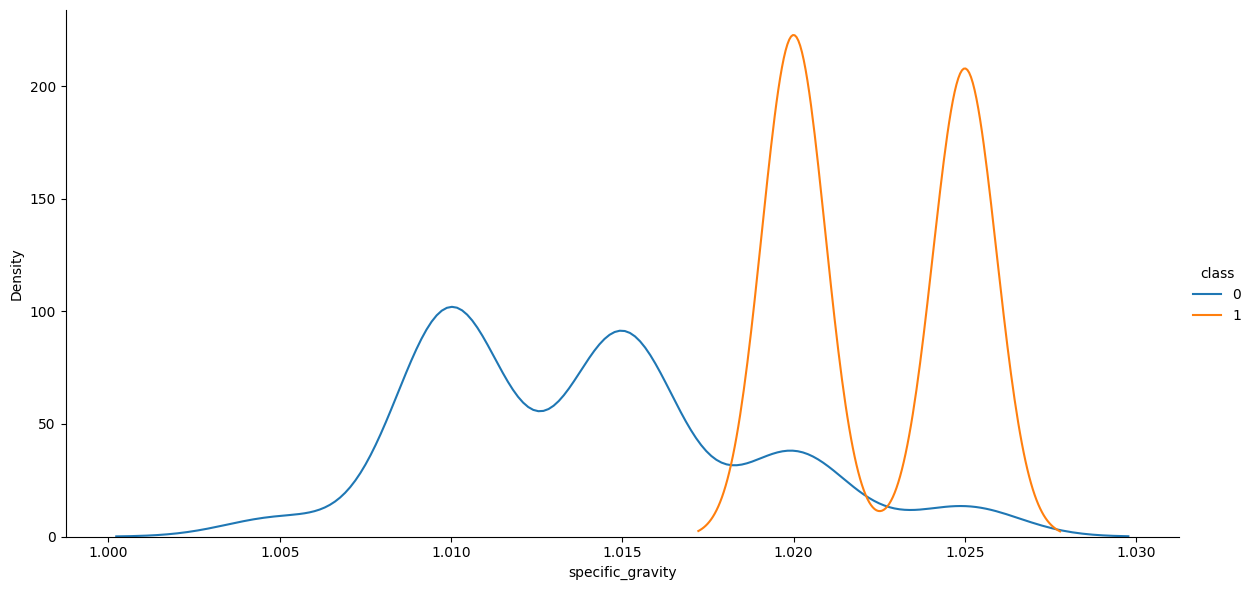

In [27]:
kde("specific_gravity")

In [28]:
df.isna().sum().sort_values(ascending=False)

,0
red_blood_cells,152
red_blood_cell_count,131
white_blood_cell_count,106
potassium,88
sodium,87
packed_cell_volume,71
pus_cell,65
hemoglobin,52
sugar,49
specific_gravity,47


In [29]:
def solve_mv_random_value(feature):

  random_sample = df[feature].dropna().sample(df[feature].isna().sum())
  random_sample.index = df[df[feature].isnull()].index
  df.loc[df[feature].isnull(),feature] = random_sample

for col in num_cols:
  solve_mv_random_value(col)

In [30]:
df[num_cols].isnull().sum()

,0
age,0
blood_presure,0
specific_gravity,0
albumin,0
sugar,0
blood_glucose_random,0
blood_urea,0
serum_creatinine,0
sodium,0
potassium,0


In [31]:
def solve_nv_mode(feature):

  mode = df[feature].mode()[0]
  df[feature] = df[feature].fillna(mode)

solve_mv_random_value("red_blood_cells")
solve_mv_random_value("pus_cell")

for col in cat_cols:
  solve_nv_mode(col)


In [32]:
df[cat_cols].isnull().sum()

,0
red_blood_cells,0
pus_cell,0
pus_cell_clumbs,0
bacteria,0
hypertension,0
diabetes_mellitus,0
coronary_artery_disease,0
appetite,0
peda_edema,0
aanemia,0


In [34]:
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

red_blood_cells: ['normal' 'abnormal']
pus_cell: ['normal' 'abnormal']
pus_cell_clumbs: ['notpresent' 'present']
bacteria: ['notpresent' 'present']
hypertension: ['yes' 'no']
diabetes_mellitus: ['yes' 'no']
coronary_artery_disease: ['no' 'yes']
appetite: ['good' 'poor']
peda_edema: ['no' 'yes']
aanemia: ['no' 'yes']
class: [0 1]


In [35]:
for col in cat_cols:
  print(f"{col}: {df[col].nunique()}")

red_blood_cells: 2
pus_cell: 2
pus_cell_clumbs: 2
bacteria: 2
hypertension: 2
diabetes_mellitus: 2
coronary_artery_disease: 2
appetite: 2
peda_edema: 2
aanemia: 2
class: 2


In [36]:
encoder =LabelEncoder()
for col in cat_cols:
  df[col] = encoder.fit_transform(df[col])

In [37]:
# Model training and testing

independent_col = [col for col in df.columns if col!="class"] # X
dependent_col = "class" # y

X = df[independent_col]
y = df[dependent_col]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [38]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [39]:
y_pred = dtc.predict(X_test)

In [40]:
dtc_accuracy = accuracy_score(y_test,y_pred)
dtc_accuracy

0.9583333333333334

In [41]:
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

In [42]:
print("Confusion Matrix: \n",cm)
print("Classification Report: \n",cr)

Confusion Matrix: 
 [[72  4]
 [ 1 43]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97        76
           1       0.91      0.98      0.95        44

    accuracy                           0.96       120
   macro avg       0.95      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



In [44]:
class_names = ["ckd","notckd"]

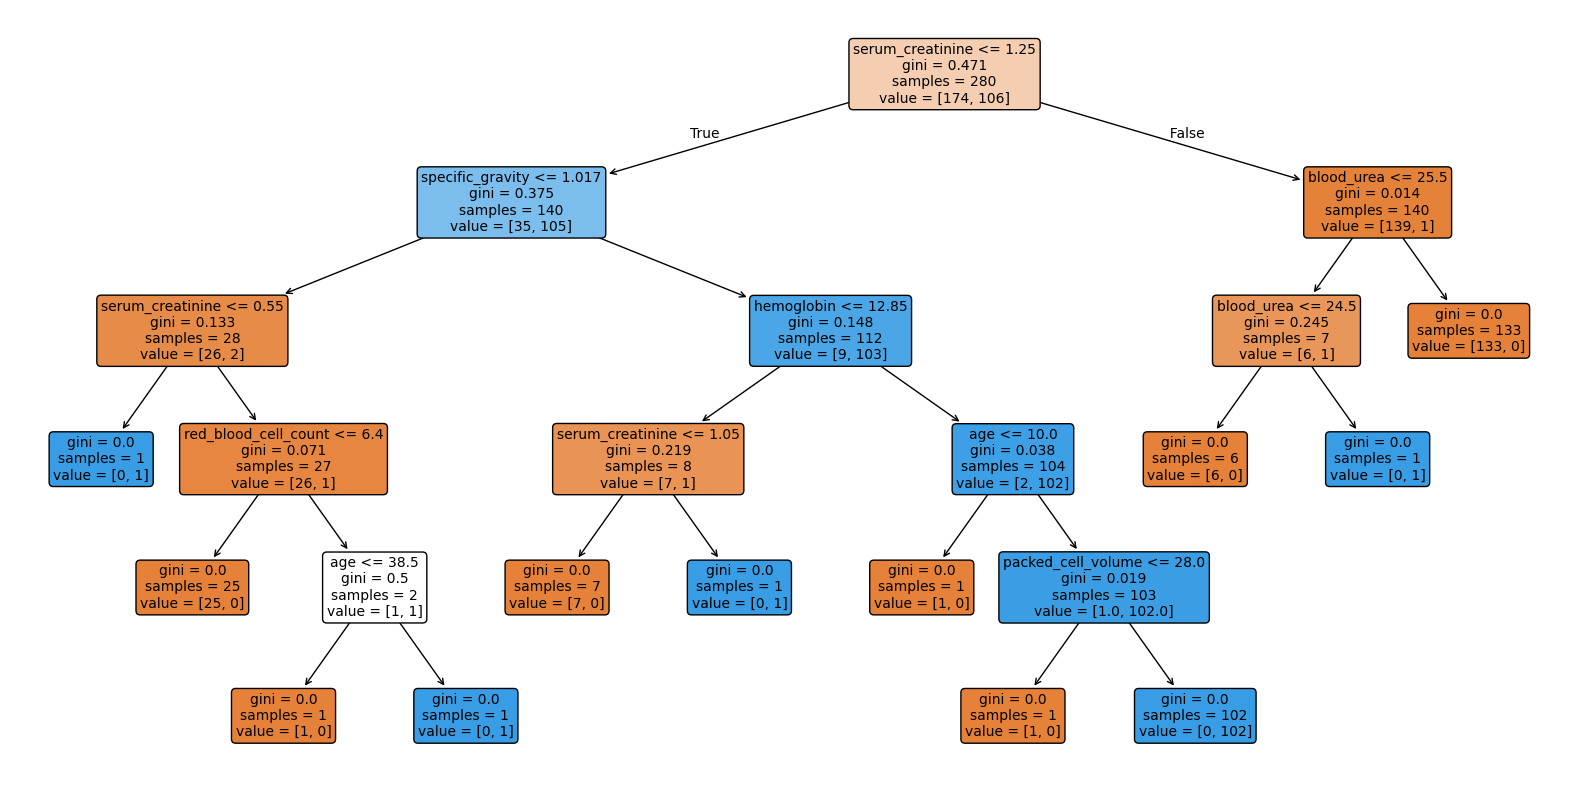

In [47]:
plt.figure(figsize=(20,10))
plot_tree(dtc,filled=True,feature_names=independent_col,rounded=True,fontsize=10)
plt.show()

In [52]:
feature_importance = pd.DataFrame({"Feature":independent_col,"Importance":dtc.feature_importances_})
feature_importance

,Feature,Importance
0,age,0.022335
1,blood_presure,0.000000
2,specific_gravity,0.244660
3,albumin,0.000000
4,sugar,0.000000
5,red_blood_cells,0.000000
6,pus_cell,0.000000
7,pus_cell_clumbs,0.000000
8,bacteria,0.000000
9,blood_glucose_random,0.000000


In [53]:
print("Most important feature:",feature_importance.sort_values(by="Importance",ascending=False))

Most important feature:                     Feature  Importance
11         serum_creatinine    0.613282
2          specific_gravity    0.244660
14               hemoglobin    0.082589
0                       age    0.022335
10               blood_urea    0.015073
15       packed_cell_volume    0.015034
17     red_blood_cell_count    0.007028
22               peda_edema    0.000000
21                 appetite    0.000000
20  coronary_artery_disease    0.000000
19        diabetes_mellitus    0.000000
18             hypertension    0.000000
16   white_blood_cell_count    0.000000
12                   sodium    0.000000
13                potassium    0.000000
1             blood_presure    0.000000
9      blood_glucose_random    0.000000
8                  bacteria    0.000000
7           pus_cell_clumbs    0.000000
6                  pus_cell    0.000000
5           red_blood_cells    0.000000
4                     sugar    0.000000
3                   albumin    0.000000
23              

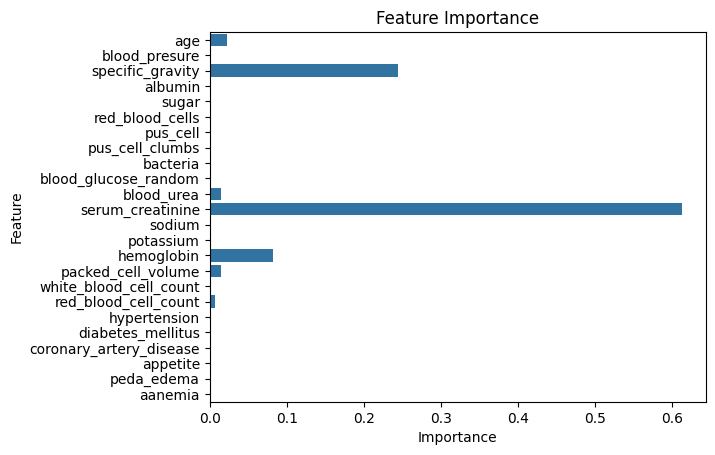

In [55]:
plt.figure()
sns.barplot(x="Importance",y="Feature",data=feature_importance)
plt.title("Feature Importance")
plt.show()